# Stage 2 · DoT pretraining

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohamedzait20003/TableMind/blob/main/src/notebooks/02_pretrain.ipynb)

Loads the memory stage from Drive and trains the full DoT model on WikiSQL: TAPAS prunes the table to the top-k tokens (question always kept), the kept tokens are decoded and re-tokenized for T5, and T5 generates the answer obtained by executing each example's SQL. Pruning scores scale the T5 input embeddings, so TAPAS is trained end to end.

**Requires:** `01_memory.ipynb` · **Next:** `03_evaluation.ipynb`

## Setup

On Colab, pick **Runtime → Change runtime type → T4 GPU** first.

In [1]:
# Environment setup: clones the repo on Colab, uses the local checkout otherwise
import os, sys
from pathlib import Path

REPO_URL = "https://github.com/mohamedzait20003/TableMind.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("/content/TableMind"):
        !git clone -q {REPO_URL} /content/TableMind
    %cd /content/TableMind
    !pip install -q -r requirements.txt
else:
    # Local run (e.g. from src/notebooks): move up to the repository root
    os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists()))

sys.path.insert(0, os.path.abspath("src"))
print("Working directory:", os.getcwd())

/content/TableMind
Working directory: /content/TableMind


In [2]:
from utils import load_config, set_seed, resolve_device, get_storage_dir

# quick.yaml: t5-small + tapas-small, small subsets (fits a free T4)
# default.yaml: t5-base + tapas-large, the full experiment
CONFIG_PATH = "src/config/quick.yaml"

config = load_config(CONFIG_PATH)
device = resolve_device(config["system"]["device"])
set_seed(config["system"]["seed"])

# Google Drive on Colab (you will be asked to authorize), ./storage locally
STORAGE = get_storage_dir(config["storage"]["drive_subdir"], config["storage"]["local_dir"])
CHECKPOINT_DIR = config["system"]["checkpoint_dir"]
OUTPUT_DIR = config["system"]["output_dir"]
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Config: {CONFIG_PATH} ({config['experiment']['name']})")
print(f"Device: {device} | storage: {STORAGE}")

Mounted at /content/drive
Config: src/config/quick.yaml (dot_model_quick)
Device: cuda | storage: /content/drive/MyDrive/TableMind/checkpoints


## Load the memory stage

In [3]:
from core import MemoryEncoder, KeyValueMemoryStore
from utils import download_checkpoint, load_checkpoint

enc_cfg = config["model"]["memory_encoder"]
memory_encoder = MemoryEncoder(model_name=enc_cfg["model_name"], proj_dim=enc_cfg["proj_dim"])
memory_store = KeyValueMemoryStore()

memory_path = download_checkpoint(config["storage"]["memory_checkpoint"], STORAGE, CHECKPOINT_DIR)
load_checkpoint(memory_path, memory_encoder, memory_store=memory_store)
print("Memory entries:", memory_store.size())

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

Checkpoint loaded: ./checkpoints/memory_stage_quick.pt
Memory entries: 5000


## Load WikiSQL

The official release (~26 MB) is downloaded once; targets come from executing each query on its table.

In [4]:
from torch.utils.data import DataLoader
from utils import WikiSQLDataset, collate_fn

train_dataset = WikiSQLDataset.from_config(config, "train")
eval_dataset = WikiSQLDataset.from_config(config, "eval")

pre_cfg = config["pretraining"]
workers = config["system"]["num_workers"]
train_loader = DataLoader(train_dataset, batch_size=pre_cfg["batch_size"], shuffle=True,
                          collate_fn=collate_fn, num_workers=workers)
eval_loader = DataLoader(eval_dataset, batch_size=pre_cfg["batch_size"],
                         collate_fn=collate_fn, num_workers=workers)

example = train_dataset.data[0]
print("Q:", example.question)
print("A:", example.answer, f"({example.aggregation.name})")
example.table.head()

tokenizer_config.json:   0%|          | 0.00/490 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/262k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/154 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

WikiSQL: kept 1127 examples, skipped 0 (malformed or empty answer)
WikiSQL: kept 421 examples, skipped 0 (malformed or empty answer)
Q: Tell me what the notes are for South Australia 
A: no slogan on current series (NONE)


,State/territory,Text/background colour,Format,Current slogan,Current series,Notes
0,Australian Capital Territory,blue/white,Yaa·nna,ACT · CELEBRATION OF A CENTURY 2013,YIL·00A,Slogan screenprinted on plate
1,New South Wales,black/yellow,aa·nn·aa,NEW SOUTH WALES,BX·99·HI,No slogan on current series
2,New South Wales,black/white,aaa·nna,NSW,CPX·12A,Optional white slimline series
3,Northern Territory,ochre/white,Ca·nn·aa,NT · OUTBACK AUSTRALIA,CB·06·ZZ,New series began in June 2011
4,Queensland,maroon/white,nnn·aaa,QUEENSLAND · SUNSHINE STATE,999·TLG,Slogan embossed on plate


## Build the DoT model

In [5]:
from core import DoTModel

model = DoTModel(
    memory_store, memory_encoder,
    k=config["model"]["pruning_transformer"]["top_k"],
    pruning_model=config["model"]["pruning_transformer"]["model_name"],
    task_model=config["model"]["task_transformer"]["model_name"],
    memory_top_k=pre_cfg["memory_top_k"],
    task_max_length=config["model"]["task_transformer"]["max_length"],
)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/1.66k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  117MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/83 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  117MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Parameters: 125,398,150


## Train

After every epoch the weights are saved and uploaded as `<experiment>_latest.pt`, so a Colab disconnect loses at most one epoch. Set `RESUMABLE = True` to also keep optimizer state (≈3× larger files).

In [6]:
from core import PretrainTrainer
from utils import save_checkpoint, upload_checkpoint

RESUMABLE = False

trainer = PretrainTrainer(
    model, train_loader, eval_loader,
    device=device,
    num_epochs=pre_cfg["num_epochs"],
    learning_rate=pre_cfg["learning_rate"],
    weight_decay=pre_cfg["weight_decay"],
    warmup_ratio=pre_cfg["warmup_ratio"],
    scheduler_type=pre_cfg["scheduler_type"],
    gradient_clipping=pre_cfg["gradient_clipping"],
    gradient_accumulation_steps=pre_cfg["gradient_accumulation_steps"],
    log_steps=pre_cfg["log_steps"],
)

def save_epoch(trainer):
    path = os.path.join(CHECKPOINT_DIR, f"{config['experiment']['name']}_latest.pt")
    save_checkpoint(path, trainer.model, memory_store=memory_store, trainer=trainer,
                    config=config, include_optimizer=RESUMABLE)
    upload_checkpoint(path, STORAGE)

trainer.train(on_epoch_end=save_epoch)

Training on cuda for 1 epoch(s), 125,398,150 trainable parameters




Epoch 1:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 1:   0%|          | 1/282 [00:02<13:42,  2.93s/it]

Epoch 1:   1%|          | 2/282 [00:03<06:27,  1.38s/it]

Epoch 1:   1%|          | 3/282 [00:03<04:09,  1.12it/s]

Epoch 1:   1%|▏         | 4/282 [00:03<02:57,  1.56it/s]

Epoch 1:   2%|▏         | 5/282 [00:04<02:19,  1.99it/s]

Epoch 1:   2%|▏         | 6/282 [00:04<01:53,  2.42it/s]

Epoch 1:   2%|▏         | 7/282 [00:04<01:44,  2.63it/s]

Epoch 1:   3%|▎         | 8/282 [00:04<01:34,  2.88it/s]

Epoch 1:   3%|▎         | 9/282 [00:05<01:36,  2.84it/s]

Epoch 1:   3%|▎         | 9/282 [00:05<01:36,  2.84it/s, loss=3.8708, lr=1.79e-05, step=10]

Epoch 1:   4%|▎         | 10/282 [00:05<01:36,  2.83it/s, loss=3.8708, lr=1.79e-05, step=10]

Epoch 1:   4%|▍         | 11/282 [00:05<01:28,  3.07it/s, loss=3.8708, lr=1.79e-05, step=10]

Epoch 1:   4%|▍         | 12/282 [00:06<01:23,  3.25it/s, loss=3.8708, lr=1.79e-05, step=10]

Epoch 1:   5%|▍         | 13/282 [00:06<02:02,  2.2

Epoch 1/1 - Train Loss: 1.7561 - eval_loss: 1.0533 - eval_token_accuracy: 0.8001
Checkpoint saved: ./checkpoints/dot_model_quick_latest.pt
Uploaded: /content/drive/MyDrive/TableMind/checkpoints/dot_model_quick_latest.pt


([1.756125709147635],
 [{'eval_loss': 1.053323768931529, 'eval_token_accuracy': 0.8000992063492064}])

Training curves saved: ./outputs/dot_model_quick_pretrain_curves.png


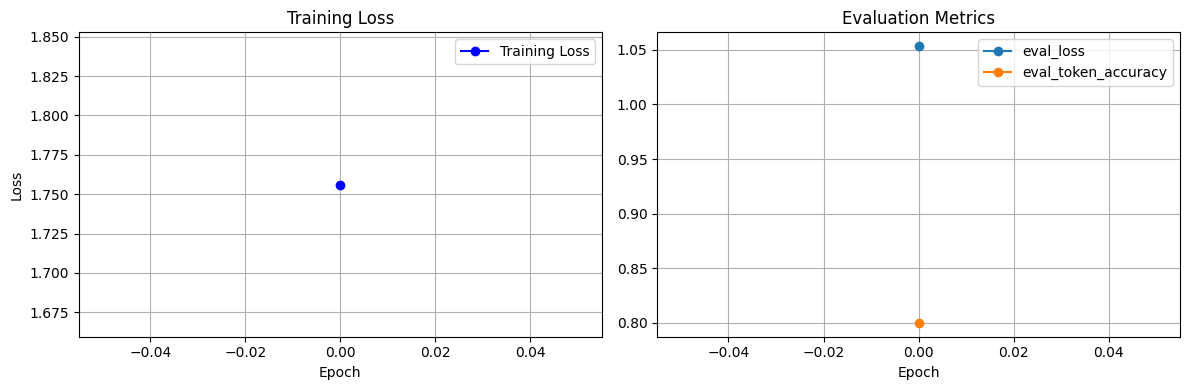

In [7]:
trainer.plot_training_curves(
    os.path.join(OUTPUT_DIR, f"{config['experiment']['name']}_pretrain_curves.png")
)

## Save and upload the final model

In [8]:
final_path = os.path.join(CHECKPOINT_DIR, config["storage"]["pretrain_checkpoint"])
save_checkpoint(final_path, model, memory_store=memory_store, trainer=trainer, config=config)
upload_checkpoint(final_path, STORAGE)

Checkpoint saved: ./checkpoints/pretrain_final_quick.pt
Uploaded: /content/drive/MyDrive/TableMind/checkpoints/pretrain_final_quick.pt


'/content/drive/MyDrive/TableMind/checkpoints/pretrain_final_quick.pt'